In [1]:
import scanpy as sc
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

from scipy.spatial import KDTree
from scipy.stats import spearmanr, pearsonr

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

In [3]:
fig_dir = f'../../results/figures/pSMAD5_T_comparison'
os.makedirs(fig_dir, exist_ok=True)

## T dataset -- `W8_pattern1_Sox17_Brachyury`

In [4]:
T_img_name = 'W8_pattern1_Sox17_Brachyury'
T_channel_names = ['Sox17', 'BMP4', 'T', 'Hoechst']

T_out = tiff.imread(os.path.join('../../data/stitched', f'{T_img_name}.tif'))
T_masks = np.load(f'../../data/stitched/{T_img_name}.npy')

T_out.shape, T_masks.shape

((4, 5996, 7937), (5996, 7937))

In [5]:
T_df = pd.read_parquet(f'../../data/stitched/{T_img_name}_features.parquet')
print(T_df.shape)
T_df.head(3)

(111511, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.058548,629.522248,427.0,85.941125,84.158813,0.603269,0.908511,0.640180,27.763694,22.142602,...,0.757598,1.253859,264.735363,124.067916,347.723653,1366.845433,False,False,False,True
2,9.803440,4872.491400,407.0,76.526912,75.233579,0.618904,0.946512,0.740000,26.030466,20.446056,...,0.903610,1.273129,216.383292,118.837838,198.417690,758.594595,False,False,False,True
3,9.231250,7124.062500,160.0,54.970563,54.796878,0.911222,0.879121,0.661157,22.911059,9.437440,...,0.669604,2.427677,226.725000,136.756250,379.668750,1362.175000,False,False,False,True


In [6]:
T_df[[f'{c}_mean' for c in T_channel_names]].describe()

,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean
count,111511.000000,111511.000000,111511.000000,111511.000000
mean,349.274175,177.115951,384.420649,1267.033692
std,736.013142,284.502758,373.982602,356.248578
min,129.917808,104.268571,119.529870,253.638961
25%,261.022235,123.608108,168.413233,1017.790086
50%,297.674121,125.513889,250.158209,1247.706150
75%,329.154763,127.966209,463.310643,1476.112706
max,49136.950980,6417.137457,44064.475836,6564.862136


3859 BMP4+ cells


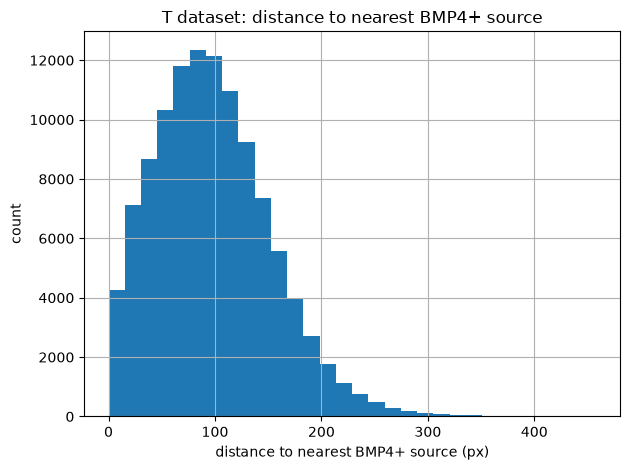

In [7]:
T_source_centroids = T_df.loc[T_df['BMP4+'], ['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
T_all_centroids = T_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

T_source_tree = KDTree(T_source_centroids)
T_dist_to_source, T_nearest_idx = T_source_tree.query(T_all_centroids, k=1)
T_df['dist_to_BMP4_source'] = T_dist_to_source

print(f"{T_df['BMP4+'].sum()} BMP4+ cells")

ax = T_df['dist_to_BMP4_source'].hist(bins=30)
ax.set_xlabel('distance to nearest BMP4+ source (px)')
ax.set_ylabel('count')
ax.set_title('T dataset: distance to nearest BMP4+ source')
plt.tight_layout()
plt.savefig(f'{fig_dir}/distribution_allcellsdist2nearestBMP4source_T.png', dpi=100)

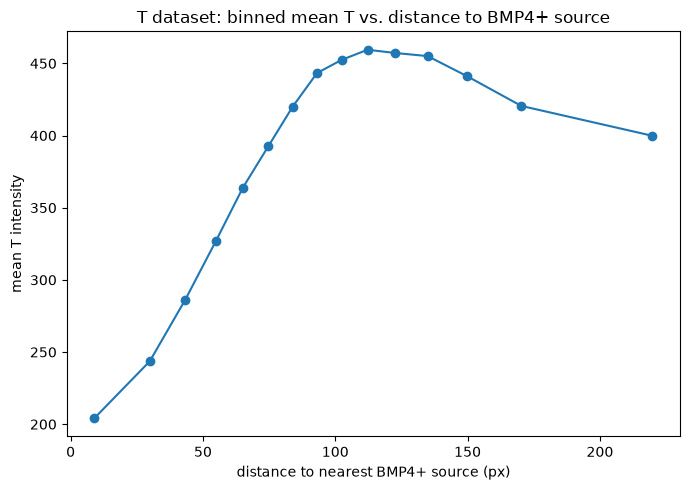

,bin_center,T_mean_avg,n
dist_to_BMP4_source,,,
"(-0.001, 22.574]",9.012436,204.250983,7435
"(22.574, 36.881]",29.898531,243.630388,7434
"(36.881, 49.341]",43.284843,286.168424,7434
"(49.341, 60.103]",54.832954,326.732038,7434
"(60.103, 69.967]",65.084119,363.899986,7434
"(69.967, 79.271]",74.685387,392.540625,7434
"(79.271, 88.505]",83.932297,420.120370,7434
"(88.505, 97.669]",93.083815,443.286427,7434
"(97.669, 107.167]",102.411795,452.448151,7434


In [8]:
N_BINS = 15
T_dist_bin = pd.qcut(T_df['dist_to_BMP4_source'], q=N_BINS, duplicates='drop')
T_binned = T_df.groupby(T_dist_bin, observed=True).agg(
    bin_center=('dist_to_BMP4_source', 'mean'),
    T_mean_avg=('T_mean', 'mean'),
    n=('T_mean', 'size'),
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T_binned['bin_center'], T_binned['T_mean_avg'], marker='o')
ax.set_xlabel('distance to nearest BMP4+ source (px)')
ax.set_ylabel('mean T intensity')
ax.set_title('T dataset: binned mean T vs. distance to BMP4+ source')
fig.tight_layout()
plt.savefig(f'{fig_dir}/T_binned_distance_response.png', dpi=100)
plt.show()

display(T_binned)

## pSMAD1/5 dataset -- `power_spots_8uW_composite`

In [9]:
pSMAD_img_name = 'power_spots_8uW_composite'
pSMAD_channel_names = ['pSMAD1/5', 'BMP4', 'Hoechst']

pSMAD_out = tiff.imread(os.path.join('../../data/stitched', f'{pSMAD_img_name}.tif'))
pSMAD_masks = np.load(f'../../data/stitched/{pSMAD_img_name}.npy')

pSMAD_out.shape, pSMAD_masks.shape

((3, 5960, 7940), (5960, 7940))

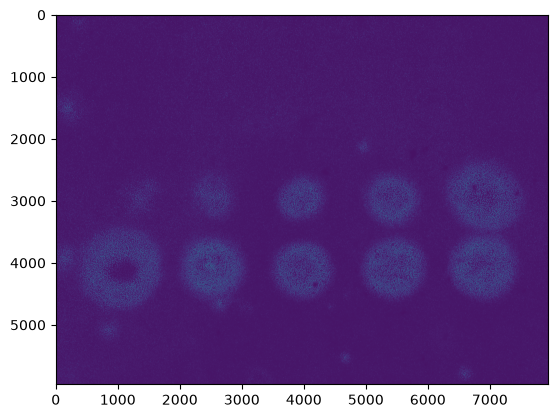

In [10]:
_ = plt.imshow(pSMAD_out[0])

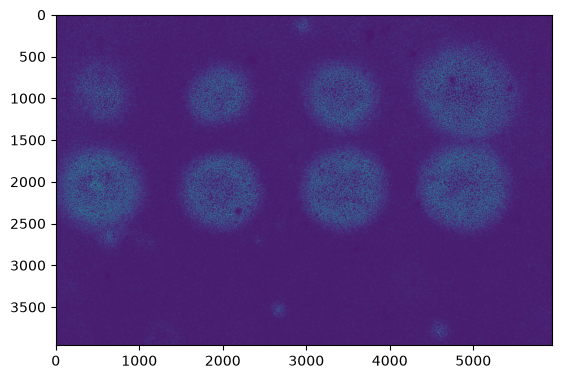

In [11]:
crop = [(2000, 5960), (2000, 7940)]
pSMAD_out = pSMAD_out[:, crop[0][0]: crop[0][1], crop[1][0]: crop[1][1]]
pSMAD_masks = pSMAD_masks[crop[0][0]: crop[0][1], crop[1][0]: crop[1][1]]
_ = plt.imshow(pSMAD_out[0])

In [12]:
pSMAD_df = pd.read_parquet(f'../../data/stitched/{pSMAD_img_name}_features.parquet')
pSMAD_df = pSMAD_df[pSMAD_df.index.isin(np.unique(pSMAD_masks))]
print(pSMAD_df.shape)
pSMAD_df.head(3)

(55178, 20)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,orientation,equivalent_diameter,circularity,aspect_ratio,pSMAD1/5_mean,BMP4_mean,Hoechst_mean,pSMAD1/5+,BMP4+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,
38197,1984.153502,4490.272727,671.0,111.396970,108.292467,0.771957,0.882895,0.573504,37.807838,24.033485,0.348578,29.229159,0.719012,1.573132,154.780924,114.418778,916.590164,False,False,True
38240,1984.840772,2491.870929,829.0,107.982756,105.055589,0.676594,0.969591,0.717128,38.030533,28.004012,-0.781961,32.488699,0.943900,1.358039,146.834741,114.928830,848.765983,False,False,True
38279,1985.510791,3249.417266,556.0,87.840620,85.959647,0.531307,0.958621,0.741333,28.998382,24.566832,-0.145141,26.606788,0.945574,1.180387,163.636691,113.537770,848.158273,False,False,True


In [13]:
pSMAD_df[[f'{c}_mean' for c in pSMAD_channel_names]].describe()

,pSMAD1/5_mean,BMP4_mean,Hoechst_mean
count,55178.000000,55178.000000,55178.000000
mean,201.850998,124.569353,938.448645
std,92.357535,69.727783,168.335957
min,113.590164,100.973684,340.221445
25%,143.861151,116.091979,820.711196
50%,157.847945,116.982906,914.701396
75%,215.244871,118.023263,1035.263647
max,668.719697,2586.325581,2901.225166


1323 BMP4+ cells


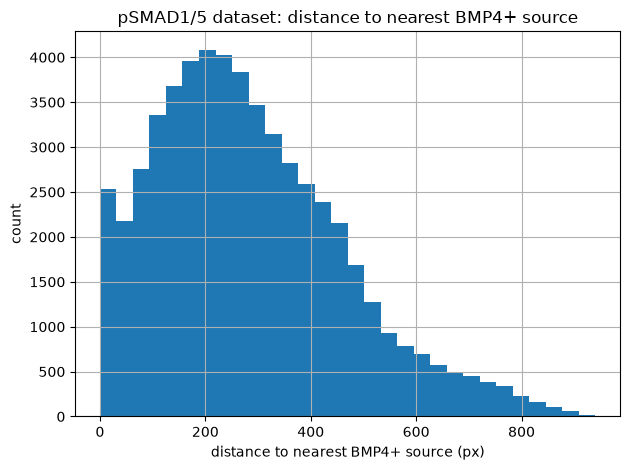

In [14]:
pSMAD_source_centroids = pSMAD_df.loc[pSMAD_df['BMP4+'], ['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
pSMAD_all_centroids = pSMAD_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

pSMAD_source_tree = KDTree(pSMAD_source_centroids)
pSMAD_dist_to_source, pSMAD_nearest_idx = pSMAD_source_tree.query(pSMAD_all_centroids, k=1)
pSMAD_df['dist_to_BMP4_source'] = pSMAD_dist_to_source

print(f"{pSMAD_df['BMP4+'].sum()} BMP4+ cells")

ax = pSMAD_df['dist_to_BMP4_source'].hist(bins=30)
ax.set_xlabel('distance to nearest BMP4+ source (px)')
ax.set_ylabel('count')
ax.set_title('pSMAD1/5 dataset: distance to nearest BMP4+ source')
plt.tight_layout()
plt.savefig(f'{fig_dir}/distribution_allcellsdist2nearestBMP4source_pSMAD.png', dpi=100)

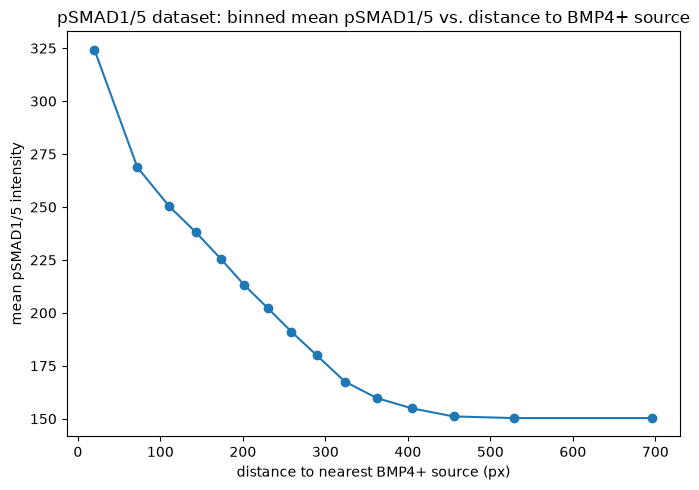

,bin_center,pSMAD_mean_avg,n
dist_to_BMP4_source,,,
"(-0.001, 49.046]",20.152154,324.264398,3679
"(49.046, 92.759]",72.125945,268.711021,3678
"(92.759, 127.146]",110.439553,250.463967,3679
"(127.146, 158.162]",142.998139,238.059805,3678
"(158.162, 187.413]",173.023818,225.639585,3679
"(187.413, 215.957]",201.727572,213.127266,3678
"(215.957, 244.075]",229.872098,202.378369,3679
"(244.075, 273.625]",258.651127,191.186266,3678
"(273.625, 305.865]",289.552027,179.972229,3679


In [15]:
N_BINS = 15
pSMAD_dist_bin = pd.qcut(pSMAD_df['dist_to_BMP4_source'], q=N_BINS, duplicates='drop')
pSMAD_binned = pSMAD_df.groupby(pSMAD_dist_bin, observed=True).agg(
    bin_center=('dist_to_BMP4_source', 'mean'),
    pSMAD_mean_avg=('pSMAD1/5_mean', 'mean'),
    n=('pSMAD1/5_mean', 'size'),
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pSMAD_binned['bin_center'], pSMAD_binned['pSMAD_mean_avg'], marker='o')
ax.set_xlabel('distance to nearest BMP4+ source (px)')
ax.set_ylabel('mean pSMAD1/5 intensity')
ax.set_title('pSMAD1/5 dataset: binned mean pSMAD1/5 vs. distance to BMP4+ source')
fig.tight_layout()
plt.savefig(f'{fig_dir}/pSMAD_binned_distance_response.png', dpi=100)
plt.show()

display(pSMAD_binned)

## Comparing T vs. pSMAD1/5 against distance to nearest BMP4+ source

`T_mean` and `pSMAD1/5_mean` live on completely different scales (T_mean ranges up
to ~44,000; pSMAD1/5_mean tops out around ~670), so overlaying raw scatter points
from both datasets on one subplot isn't meaningful. Instead:

- **Left panel**: each dataset's y-values are collapsed to a Gaussian-kernel-weighted
  local mean (a KDE-weighted / Nadaraya-Watson regression) plotted against distance,
  each on its own y-axis (twin axes) -- so the *shape* of the trend is directly
  comparable even though the *magnitudes* aren't.
- **Right panel**: Spearman/Pearson correlation vs. distance cutoff for both
  datasets, on one shared axis -- correlation is already scale-free ([-1, 1]), so no
  twin axis is needed there.

In [16]:
def p_to_stars(p):
    if p < 1e-4:
        return '****'
    elif p < 1e-3:
        return '***'
    elif p < 1e-2:
        return '**'
    elif p < 5e-2:
        return '*'
    return 'ns'

def kde_weighted_mean(x, y, x_grid, bandwidth):
    """Gaussian-kernel-weighted local mean of y at each point in x_grid (Nadaraya-Watson estimator)."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    weights = np.exp(-0.5 * ((x_grid[:, None] - x[None, :]) / bandwidth) ** 2)
    return (weights @ y) / weights.sum(axis=1)


In [17]:
# Exclude sender cells
T_df = T_df[~T_df['BMP4+']]
pSMAD_df = pSMAD_df[~pSMAD_df['BMP4+']] 
# make the datasets comparable (distance range is larger for pSMAD dataset)
pSMAD_df = pSMAD_df[(pSMAD_df['dist_to_BMP4_source'] <= max(T_df['dist_to_BMP4_source'])) & (pSMAD_df['dist_to_BMP4_source'] >= 25)]
# measure from the "edge" of the senders
T_df = T_df[(T_df['dist_to_BMP4_source'] >= min(pSMAD_df['dist_to_BMP4_source']))] 


In [18]:
DATASETS = {
    'T': {'df': T_df, 'y_col': 'T_mean', 'color': 'tab:blue'},
    'pSMAD1/5': {'df': pSMAD_df, 'y_col': 'pSMAD1/5_mean', 'color': 'tab:orange'},
}

T: Spearman r=0.294 (p=0.00e+00, ****), Pearson r=0.097 (p=1.60e-215, ****)
pSMAD1/5: Spearman r=-0.359 (p=0.00e+00, ****), Pearson r=-0.428 (p=0.00e+00, ****)


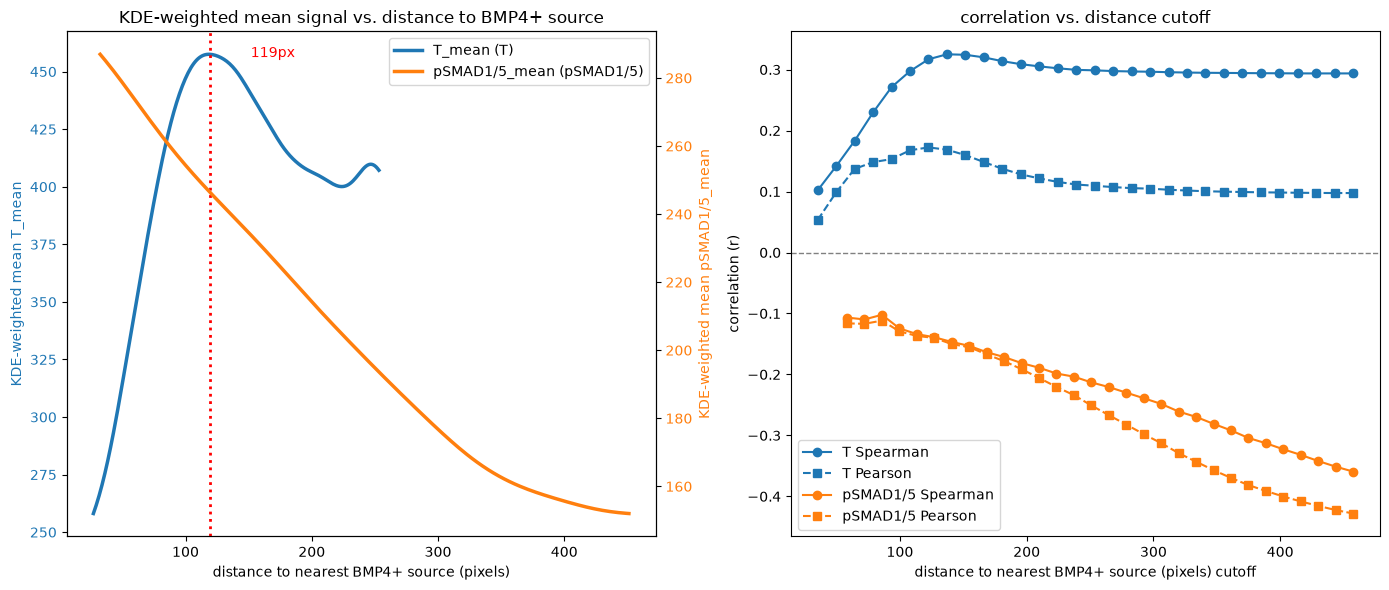

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- left panel: KDE-weighted mean trend, one y-axis per dataset -------------
ax_left = {'T': axes[0], 'pSMAD1/5': axes[0].twinx()}
lines = []
x_grid_by_name = {}
y_smooth_by_name = {}
for name, spec in DATASETS.items():
    df, y_col, color = spec['df'], spec['y_col'], spec['color']
    dist = df['dist_to_BMP4_source'].to_numpy()
    x_grid = np.linspace(np.percentile(dist, 1), np.percentile(dist, 99), 200)
    bandwidth = dist.std() / 5
    y_smooth = kde_weighted_mean(dist, df[y_col].to_numpy(), x_grid, bandwidth)
    x_grid_by_name[name] = x_grid
    y_smooth_by_name[name] = y_smooth

    ax = ax_left[name]
    line, = ax.plot(x_grid, y_smooth, color=color, linewidth=2.5, label=f'{y_col} ({name})')
    ax.set_ylabel(f'KDE-weighted mean {y_col}', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    lines.append(line)

# mark the peak of the T_mean KDE-weighted mean curve
t_peak_idx = np.argmax(y_smooth_by_name['T'])
x_peak = x_grid_by_name['T'][t_peak_idx]
axes[0].axvline(x_peak, color='red', linestyle=':', linewidth=2)
axes[0].text(x_peak + 50, 0.97, f'{x_peak:.0f}px', color='red', ha='center', va='top',
             transform=axes[0].get_xaxis_transform(),
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

axes[0].set_xlabel('distance to nearest BMP4+ source (pixels)')
axes[0].set_title('KDE-weighted mean signal vs. distance to BMP4+ source')
axes[0].legend(handles=lines, loc='upper right')

# --- right panel: correlation vs. distance cutoff, both datasets on one axis -
for name, spec in DATASETS.items():
    df, y_col, color = spec['df'], spec['y_col'], spec['color']
    r_s, p_s = spearmanr(df['dist_to_BMP4_source'], df[y_col])
    r_p, p_p = pearsonr(df['dist_to_BMP4_source'], df[y_col])
    print(f"{name}: Spearman r={r_s:.3f} (p={p_s:.2e}, {p_to_stars(p_s)}), "
          f"Pearson r={r_p:.3f} (p={p_p:.2e}, {p_to_stars(p_p)})")

    cutoffs = np.linspace(df['dist_to_BMP4_source'].quantile(0.05), df['dist_to_BMP4_source'].max(), 30)
    spearman_by_cutoff, pearson_by_cutoff = [], []
    for c in cutoffs:
        sub = df[df['dist_to_BMP4_source'] <= c]
        spearman_by_cutoff.append(spearmanr(sub['dist_to_BMP4_source'], sub[y_col])[0])
        pearson_by_cutoff.append(pearsonr(sub['dist_to_BMP4_source'], sub[y_col])[0])

    axes[1].plot(cutoffs, spearman_by_cutoff, marker='o', color=color, linestyle='-', label=f'{name} Spearman')
    axes[1].plot(cutoffs, pearson_by_cutoff, marker='s', color=color, linestyle='--', label=f'{name} Pearson')

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('distance to nearest BMP4+ source (pixels) cutoff')
axes[1].set_ylabel('correlation (r)')
axes[1].set_title('correlation vs. distance cutoff')
axes[1].legend()

fig.tight_layout()
plt.savefig(f'{fig_dir}/T_vs_pSMAD_distance_comparison.png', dpi=150)

T: Spearman r=0.294 (p=0.00e+00, ****)
pSMAD1/5: Spearman r=-0.359 (p=0.00e+00, ****)


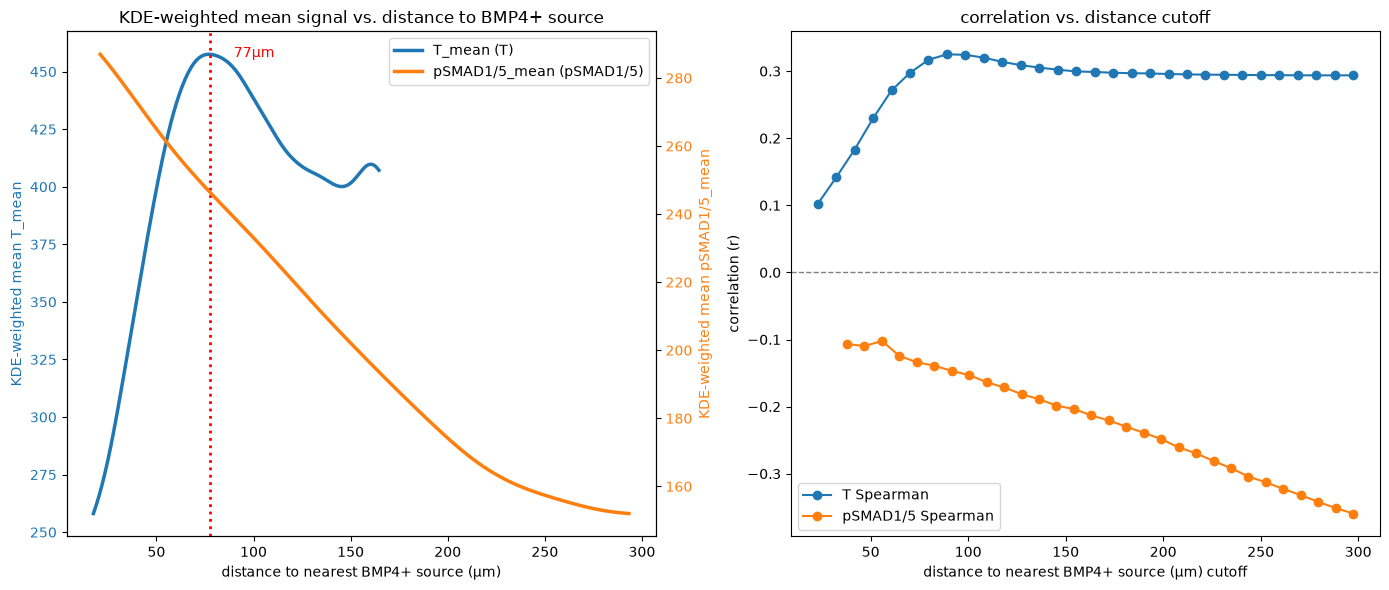

In [20]:
UM_PER_PIXEL = 0.65

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- left panel: KDE-weighted mean trend, one y-axis per dataset -------------
ax_left = {'T': axes[0], 'pSMAD1/5': axes[0].twinx()}
lines = []
x_grid_by_name = {}
y_smooth_by_name = {}
for name, spec in DATASETS.items():
    df, y_col, color = spec['df'], spec['y_col'], spec['color']
    dist_um = df['dist_to_BMP4_source'].to_numpy() * UM_PER_PIXEL
    x_grid = np.linspace(np.percentile(dist_um, 1), np.percentile(dist_um, 99), 200)
    bandwidth = dist_um.std() / 5
    y_smooth = kde_weighted_mean(dist_um, df[y_col].to_numpy(), x_grid, bandwidth)
    x_grid_by_name[name] = x_grid
    y_smooth_by_name[name] = y_smooth

    ax = ax_left[name]
    line, = ax.plot(x_grid, y_smooth, color=color, linewidth=2.5, label=f'{y_col} ({name})')
    ax.set_ylabel(f'KDE-weighted mean {y_col}', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    lines.append(line)

# mark the peak of the T_mean KDE-weighted mean curve
t_peak_idx = np.argmax(y_smooth_by_name['T'])
x_peak = x_grid_by_name['T'][t_peak_idx]
axes[0].axvline(x_peak, color='red', linestyle=':', linewidth=2)
axes[0].text(x_peak + 23, 0.97, f'{x_peak:.0f}µm', color='red', ha='center', va='top',
             transform=axes[0].get_xaxis_transform(),
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

axes[0].set_xlabel('distance to nearest BMP4+ source (µm)')
axes[0].set_title('KDE-weighted mean signal vs. distance to BMP4+ source')
axes[0].legend(handles=lines, loc='upper right')

# --- right panel: correlation vs. distance cutoff, both datasets on one axis -
for name, spec in DATASETS.items():
    df, y_col, color = spec['df'], spec['y_col'], spec['color']
    dist_um = df['dist_to_BMP4_source'].to_numpy() * UM_PER_PIXEL
    y_vals = df[y_col].to_numpy()
    r_s, p_s = spearmanr(dist_um, y_vals)
    # r_p, p_p = pearsonr(dist_um, y_vals)
    # print(f"{name}: Spearman r={r_s:.3f} (p={p_s:.2e}, {p_to_stars(p_s)}), "
    #       f"Pearson r={r_p:.3f} (p={p_p:.2e}, {p_to_stars(p_p)})")
    print(f"{name}: Spearman r={r_s:.3f} (p={p_s:.2e}, {p_to_stars(p_s)})")

    cutoffs = np.linspace(np.quantile(dist_um, 0.05), dist_um.max(), 30)
    spearman_by_cutoff, pearson_by_cutoff = [], []
    for c in cutoffs:
        mask = dist_um <= c
        spearman_by_cutoff.append(spearmanr(dist_um[mask], y_vals[mask])[0])
        # pearson_by_cutoff.append(pearsonr(dist_um[mask], y_vals[mask])[0])

    axes[1].plot(cutoffs, spearman_by_cutoff, marker='o', color=color, linestyle='-', label=f'{name} Spearman')
    # axes[1].plot(cutoffs, pearson_by_cutoff, marker='s', color=color, linestyle='--', label=f'{name} Pearson')

axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('distance to nearest BMP4+ source (µm) cutoff')
axes[1].set_ylabel('correlation (r)')
axes[1].set_title('correlation vs. distance cutoff')
axes[1].legend()

fig.tight_layout()
plt.savefig(f'{fig_dir}/T_vs_pSMAD_distance_comparison_um.png', dpi=150)